In [20]:
import os
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import joblib

import faiss
import sqlite3

from sklearn.decomposition import PCA
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import plotly.graph_objects as go

ROOT = Path.cwd().parents[1]

EMBED_PATH = ROOT / "data/embeddings/base_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

IMAGE_DIR = ROOT / "images/ellipsoid" / EMBED_NAME
CACHE_DIR = ROOT / "data/cache" / EMBED_NAME
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [21]:
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [22]:
embeds = torch.load(EMBED_PATH, weights_only=False)
cls_tokens = embeds["cls_tokens"]
patches = embeds["patches"]

In [23]:
conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)
categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()
types_per_cat = pd.read_sql_query("""
    SELECT category, COUNT(DISTINCT type) AS num_types
    FROM meta
    GROUP BY category
""", conn)
max_types = types_per_cat["num_types"].max()

conn.close()

In [24]:
def load_or_compute(path, model_path, fn):
    if path.exists() and model_path.exists():
        print("Loading ", path)
        return np.load(path), joblib.load(model_path)
    
    print("Computing ", path)
    coords, model = fn()
    
    np.save(path, coords)
    joblib.dump(model, model_path)
    return coords, model

In [25]:
def compute_pca():
    pca = PCA(n_components=2)
    coords = pca.fit_transform(cls_tokens)
    return coords, pca

Loading  c:\Projects\UL-Summer-Bursary-2026\data\cache\base_embeds\cls_pca.npy


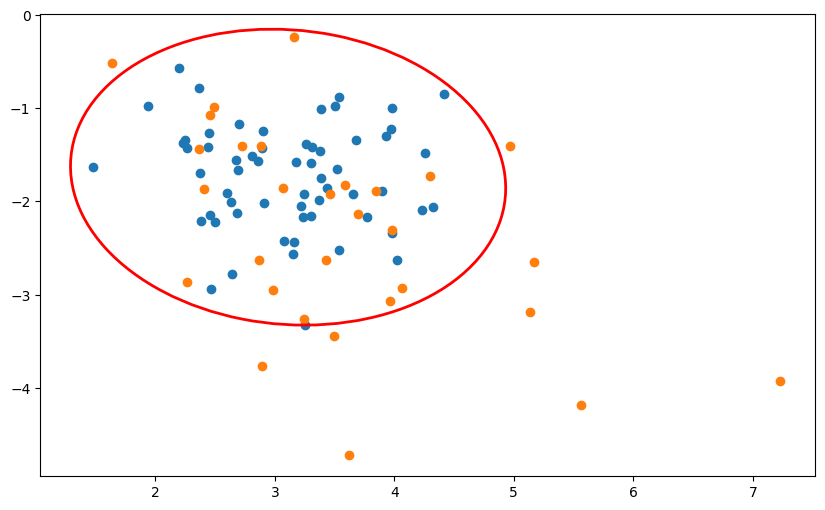

In [57]:
category = "toothbrush"

train_mask = meta["split"] == "train"
train_meta = meta[train_mask]
test_meta = meta[~train_mask]

train_cat_mask = train_meta["category"] == category

good_test_cat_mask = (test_meta["category"] == category) & (test_meta["type"] == "good")
defect_test_cat_mask = (test_meta["category"] == category) & (test_meta["type"] != "good")

pca_2d, pca = load_or_compute(CACHE_DIR / "cls_pca.npy", CACHE_DIR / "pca.joblib", compute_pca)
pca_train = pca_2d[train_mask]
pca_test = pca_2d[~train_mask]

train_2d = pca_train[train_cat_mask]
test_2d = pca_test[defect_test_cat_mask]

center = train_2d.mean(axis=0)

cov = np.cov(train_2d.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = np.linalg.pinv(cov)

diff = train_2d - center
d2 = np.einsum("ij, jk, ik->i", diff, cov_inv, diff)

ch2 = d2.max()

eigvals, eigvecs = np.linalg.eigh(cov)

order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

width = 2 * np.sqrt(eigvals[0] * ch2)
height = 2 * np.sqrt(eigvals[1] * ch2)

angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=train_2d[:, 0], y=train_2d[:, 1])
ax.scatter(x=test_2d[:, 0], y=test_2d[:, 1])

ellipse = Ellipse(
    xy=center,
    width=width,
    height=height,
    angle=angle,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

ax.add_patch(ellipse)
plt.show()

Cat length:  60
frac: 0.025
K: 2
most compact idx: 6
avg KNN dist: 42.982735
frac: 0.05
K: 3
most compact idx: 6
avg KNN dist: 57.01828
frac: 0.1
K: 6
most compact idx: 42
avg KNN dist: 70.904686


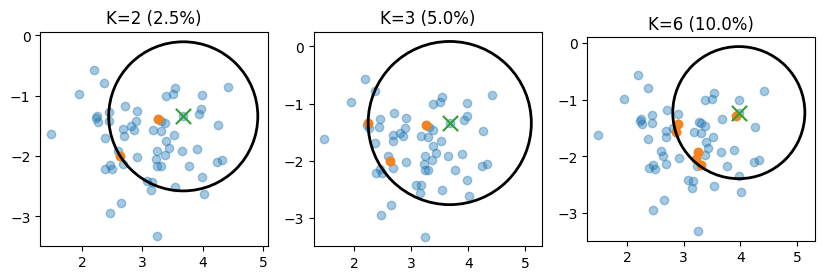

In [58]:
train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for i, frac in enumerate([0.025, 0.05, 0.10]):
    K = max(2, int(frac * len(cat_emb)))

    index = faiss.IndexFlatL2(cat_emb.shape[1])
    index.add(cat_emb.astype("float32"))

    D, I = index.search(
        cat_emb.astype("float32"),
        k=K+1 # Nearest is itself
    )

    D = D[:, 1:]    # Remove self
    I = I[:, 1:]

    avg_knn = D.mean(axis=1)

    most_compact_idx = avg_knn.argmin()
    neighbours = I[most_compact_idx]
    
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    radius_2d = np.linalg.norm(neighbours_2d - center_2d, axis=1).max()

    ax = axes[i]
    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9)
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120)

    circle = Circle(
        center_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"K={K} ({frac*100:.1f}%)")
    ax.set_aspect("equal", adjustable="box")

    print("frac:", frac)
    print("K:", K)
    print("most compact idx:", most_compact_idx)
    print("avg KNN dist:", avg_knn[most_compact_idx])

plt.show()


Cat length:  60
RUN:  1
K: 3
Neighbours Shape:  (3, 2)
Covered Shape:  (4, 2)
Growth:  1.0
RUN:  1
K: 3
Neighbours Shape:  (3, 2)
Covered Shape:  (4, 2)
Growth:  1.025
RUN:  1
K: 3
Neighbours Shape:  (3, 2)
Covered Shape:  (4, 2)
Growth:  1.05
RUN:  1
K: 3
Neighbours Shape:  (3, 2)
Covered Shape:  (4, 2)
Growth:  1.1


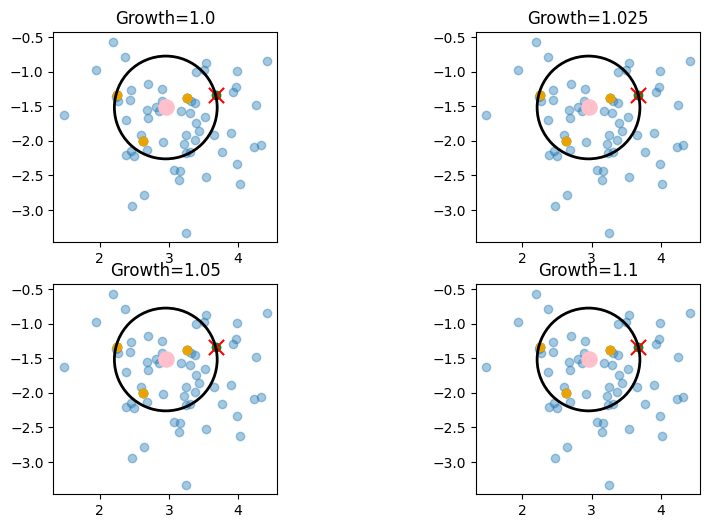

In [59]:
train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

K = max(2, int(0.05 * len(cat_emb)))

index = faiss.IndexFlatL2(cat_emb.shape[1])
index.add(cat_emb.astype("float32"))

D, I = index.search(
    cat_emb.astype("float32"),
    k=K+1 # Nearest is itself
)

D = D[:, 1:]    # Remove self
I = I[:, 1:]

avg_knn = D.mean(axis=1)

most_compact_idx = avg_knn.argmin()
neighbours = I[most_compact_idx]

center = cat_emb[most_compact_idx]
radius = np.sqrt(D[most_compact_idx, -1])

distances = np.linalg.norm(cat_emb - center, axis=1)

covered_mask = distances <= radius
covered_idx = np.where(covered_mask)[0]


for i, growth in enumerate([1.00, 1.025, 1.05, 1.10]):
    ax = axes[i]

    j = 1
    while True:
        print("RUN: ", j)
        centroid = cat_emb[covered_idx].mean(axis=0)

        radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()
        radius *= growth

        distances = np.linalg.norm(cat_emb - centroid, axis=1)
        new_covered_idx = np.where(distances <= radius)[0]

        if np.array_equal(np.sort(new_covered_idx), np.sort(covered_idx)):
            break

        covered_idx = new_covered_idx
        j += 1

    centroid = cat_emb[covered_idx].mean(axis=0)
    radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9, color="orange")
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120, color="red")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"Growth={growth}")
    ax.set_aspect("equal", adjustable="box")

    print("K:", K)

    print("Neighbours Shape: ", neighbours_2d.shape)
    print("Covered Shape: ", covered_2d.shape)

    print("Growth: ", growth)

plt.show()

In [60]:
def clean_candidate(covered_idx, cat_emb, uncovered_mask, min_points=1):

    while len(covered_idx) > min_points:
        centroid = cat_emb[covered_idx].mean(axis=0)

        d_self = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1)
        radius = d_self.max()

        d_all = np.linalg.norm(cat_emb - centroid, axis=1)
        inside_all = np.where(d_all <= radius)[0]

        shared_count = np.sum(~uncovered_mask[inside_all])

        if shared_count == 0:
            return covered_idx, centroid, radius

        # remove point causing the current sphere to stretch the most
        worst_local = d_self.argmax()
        covered_idx = np.delete(covered_idx, worst_local)

    centroid = cat_emb[covered_idx].mean(axis=0)
    radius = 0.0 if len(covered_idx) == 1 else np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    return covered_idx, centroid, radius

In [61]:
uncovered_mask = np.ones(len(cat_emb), dtype=bool)
spheres = []

K_frac = 0.05

start_growth = 1.05
min_growth = 1

while uncovered_mask.any():
    uncovered_idx = np.where(uncovered_mask)[0]
    uncovered_emb = cat_emb[uncovered_idx].astype("float32")

    K = max(2, int(K_frac * len(uncovered_idx)))
    K = min(K, len(uncovered_idx) - 1)

    growth = max(min_growth, start_growth - 0.0025 * len(spheres))
    if K < 1:
        covered_idx = uncovered_idx
        centroid = cat_emb[covered_idx].mean(axis=0)
        radius = 0.0
    else:
        index = faiss.IndexFlatL2(uncovered_emb.shape[1])
        index.add(uncovered_emb)

        D, I = index.search(uncovered_emb.astype("float32"), k=K+1) # +1 as nearest is itself 

        D = D[:, 1:]    # Remove self
        I = I[:, 1:]

        avg_knn = D.mean(axis=1)

        local_compact  = avg_knn.argmin()
        neighbours_local = I[local_compact]

        full_covered_idx = uncovered_idx[np.r_[local_compact, neighbours_local]]

        covered_idx, centroid, radius = clean_candidate(
            full_covered_idx,
            cat_emb,
            uncovered_mask,
            min_points=1
        )

        if len(full_covered_idx) == len(covered_idx):
            while True:
                old_covered_idx = covered_idx.copy()
                
                search_radius = radius * growth
                distances = np.linalg.norm(cat_emb - centroid, axis=1)

                candidate_idx = np.where(distances <= search_radius)[0]
                full_new_covered_idx = candidate_idx[uncovered_mask[candidate_idx]]
                
                new_covered_idx, new_centroid, new_radius = clean_candidate(full_new_covered_idx, cat_emb, uncovered_mask, min_points=len(old_covered_idx)) 

                if len(new_covered_idx) > len(old_covered_idx):
                    covered_idx = new_covered_idx
                    centroid = new_centroid
                    radius = new_radius
                else:
                    break

            centroid = cat_emb[covered_idx].mean(axis=0)
            radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    spheres.append({
        "center": centroid,
        "radius": radius,
        "covered_idx": covered_idx
    })

    uncovered_mask[covered_idx] = False
    
    # print(
    #     f"Sphere {len(spheres)} | "
    #     f"covered={len(covered_idx)} | "
    #     f"remaining={uncovered_mask.sum()} | "
    #     f"radius={radius:.4f}"
    # )

spheres_df = pd.DataFrame(spheres)
spheres_df

,center,radius,covered_idx
0,"[1.5039084, -1.051369, 4.465118, -0.5565269, -...",6.102463,"[6, 15, 8, 10]"
1,"[1.4124155, -0.85281485, 4.6235175, -0.2927215...",5.561434,"[7, 9, 1]"
2,"[2.4409702, -0.15037024, 3.8780315, -0.2053252...",4.889994,"[58, 42, 43]"
3,"[2.222805, -0.23150158, 4.0932097, 0.11154797,...",5.411763,"[47, 48, 46]"
4,"[1.6049751, -0.7987502, 4.0923066, -0.5762637,...",6.288547,"[12, 13, 4]"
5,"[1.6392063, -0.94153863, 3.6175005, -0.0278443...",5.701743,"[14, 2, 19]"
6,"[2.139472, -0.4476067, 4.1806965, 0.9307963, -...",5.819024,"[23, 22, 38]"
7,"[1.7014222, -0.8736561, 3.6926777, -0.28974333...",6.305914,"[11, 0, 18]"
8,"[2.2437584, -0.56476593, 4.170259, 0.47458872,...",6.728044,"[32, 35, 20]"
9,"[2.2918751, -0.35910836, 3.6888554, -0.8239133...",7.222694,"[49, 55, 56]"


In [62]:
overlaps = []

for i, j in combinations(range(len(spheres)), 2):
    c1 = spheres[i]["center"]
    c2 = spheres[j]["center"]

    r1 = spheres[i]["radius"]
    r2 = spheres[j]["radius"]

    centre_dist = np.linalg.norm(c1 - c2)
    overlap_amount = (r1+r2) - centre_dist
    
    dist_to_c1 = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - c1, axis=1) 
    dist_to_c2 = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - c2, axis=1) 

    c1_overlap_count = np.sum(dist_to_c1 <= r1)
    c2_overlap_count = np.sum(dist_to_c2 <= r2)

    overlaps.append({
        "sphere_i": i,
        "sphere_j": j,
        "centre_dist": centre_dist,
        "add_radii": r1 + r2,
        "overlap": overlap_amount > 0,
        "overlap_amount": max(0, overlap_amount),
        "j_points_inside_i": c1_overlap_count,
        "i_points_inside_j": c2_overlap_count
    })

overlap_df = pd.DataFrame(overlaps)

overlap_df.to_csv(RESULTS_DIR / "sphere_overlaps.csv")
overlap_df

,sphere_i,sphere_j,centre_dist,add_radii,overlap,overlap_amount,j_points_inside_i,i_points_inside_j
0,0,1,6.710897,11.663897,True,4.953000,0,0
1,0,2,14.992803,10.992456,False,0.000000,0,0
2,0,3,15.969451,11.514225,False,0.000000,0,0
3,0,4,7.993547,12.391010,True,4.397463,0,0
4,0,5,7.522758,11.804206,True,4.281448,0,0
...,...,...,...,...,...,...,...,...
205,17,19,10.996202,12.632589,True,1.636388,0,0
206,17,20,12.425898,16.079012,True,3.653114,0,0
207,18,19,14.864820,13.253790,False,0.000000,0,0
208,18,20,14.142998,16.700212,True,2.557215,0,0


In [63]:
num_overlap = overlap_df["overlap"].sum()

num_overlap

np.int64(112)

In [64]:
overlapped_points = set()

for _, row in overlap_df.iterrows():
    i = int(row["sphere_i"])
    j = int(row["sphere_j"])

    # points owned by j that are inside i
    dist_j_to_i = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - spheres[i]["center"], axis=1)
    overlapped_points.update(spheres[j]["covered_idx"][dist_j_to_i <= spheres[i]["radius"]])

    # points owned by i that are inside j
    dist_i_to_j = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - spheres[j]["center"], axis=1)
    overlapped_points.update(spheres[i]["covered_idx"][dist_i_to_j <= spheres[j]["radius"]])

len(overlapped_points), len(overlapped_points) / len(cat_emb)

(0, 0.0)

In [65]:
test_emb = cls_tokens[~train_mask]
defect_test_emb = test_emb[defect_test_cat_mask]
good_test_emb = test_emb[good_test_cat_mask]

overlaps = {"good": 0, "defect": 0}
for s in spheres:
    centroid = s["center"]
    radius = s["radius"]

    good_distances = np.linalg.norm(good_test_emb - centroid, axis=1)
    good_in_area = np.where(good_distances <= radius)[0]

    defect_distances = np.linalg.norm(defect_test_emb - centroid, axis=1)
    defect_in_area = np.where(defect_distances <= radius)[0]

    overlaps["good"] += len(good_in_area)
    overlaps["defect"] += len(defect_in_area)

print("Good Amount: ", len(good_test_emb))
print("Defect Amount: ", len(defect_test_emb))
print(overlaps)


Good Amount:  12
Defect Amount:  30
{'good': 0, 'defect': 0}


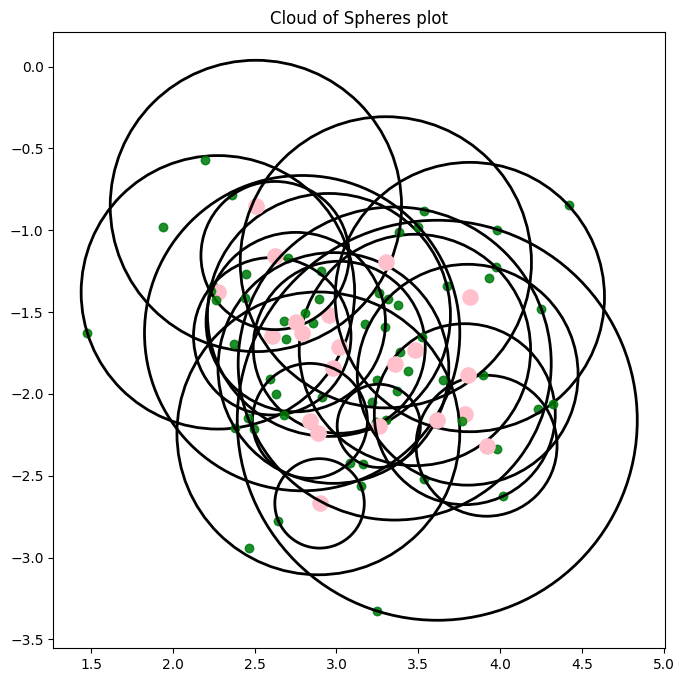

In [66]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)

for sphere in spheres:
    centroid = sphere["center"]
    covered_idx = sphere["covered_idx"]

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)

ax.set_title("Cloud of Spheres plot")
ax.set_aspect("equal", adjustable="box")

plt.show()

In [67]:
def sphere_surface(center, radius, resolution=20):
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)

    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

    return x, y, z

In [68]:
pca3 = PCA(n_components=3)
pca_3d = pca3.fit_transform(cls_tokens)

pca_train_3d = pca_3d[train_mask]
pca_cat_3d = pca_train_3d[train_cat_mask]

In [69]:
rng = np.random.default_rng(42)

colours = [
    f"rgb({r},{g},{b})"
    for r, g, b in rng.integers(30, 255, size=(len(spheres), 3))
]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=pca_cat_3d[:, 0],
    y=pca_cat_3d[:, 1],
    z=pca_cat_3d[:, 2],
    mode="markers",
    marker=dict(size=3, opacity=0.35),
    name="all screw train"
))

for i, s in enumerate(spheres):
    idx = s["covered_idx"]
    pts = pca_cat_3d[idx]

    center_3d = pts.mean(axis=0)
    radius_3d = np.linalg.norm(pts - center_3d).max()

    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(size=4, color=colours[i]),
        name=f"sphere {i+1}",
        legendgroup=f"sphere{i}"
    ))

    fig.add_trace(go.Scatter3d(
        x=[center_3d[0]],
        y=[center_3d[1]],
        z=[center_3d[2]],
        mode="markers",
        marker=dict(size=7, symbol="x", color=colours[i]),
        name=f"center {i+1}",
        showlegend=False,
        legendgroup=f"sphere{i}"
    ))

    xs, ys, zs = sphere_surface(center_3d, radius_3d, resolution=20)

    fig.add_trace(go.Surface(
        x=xs,
        y=ys,
        z=zs,
        opacity=0.12,
        showscale=False,
        name=f"Boundary {i+1}",
        legendgroup=f"sphere{i}",
        showlegend=False
    ))

fig.update_layout(
    title="3D PCA multi-sphere assignment view",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=750,
    updatemenus=[
    dict(
        type="buttons",
        buttons=[
            dict(
                label="Show All",
                method="update",
                args=[{"visible": [True] * len(fig.data)}]
            ),
            dict(
                label="Hide All",
                method="update",
                args=[{"visible": ["legendonly"] * len(fig.data)}]
            )
        ],
        x=1.15,
        y=0
    )
    ]
)

fig.show()